In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    StackingRegressor,
    VotingRegressor
)
from xgboost import XGBRegressor




import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("/home/noir/Documents/GITHUB_REPOS/MACHINE_LEARNING/Data/bangladesh_student_performance.csv")
df.head()

,date,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result,hsc_result
0,29/04/2018,M,18,Rural,GT3,Together,3,2,At_home,Farmer,No,No,71672,4,4.22,3.72
1,29/04/2018,F,19,Rural,LE3,Apart,0,4,Other,Health,Yes,No,26085,5,3.47,2.62
2,29/04/2018,F,19,Rural,GT3,Together,0,3,Teacher,Services,No,No,40891,3,3.32,2.56
3,29/04/2018,F,19,Rural,LE3,Apart,2,3,At_home,Business,No,No,50600,2,4.57,4.17
4,29/04/2018,M,17,Rural,GT3,Together,1,1,At_home,Farmer,No,No,62458,2,4.50,3.94


In [3]:
print(df.shape)
df.info()
df.describe().T

(2018, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2018 entries, 0 to 2017
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          2018 non-null   object 
 1   gender        2018 non-null   object 
 2   age           2018 non-null   int64  
 3   address       2018 non-null   object 
 4   famsize       2018 non-null   object 
 5   Pstatus       2018 non-null   object 
 6   M_Edu         2018 non-null   int64  
 7   F_Edu         2018 non-null   int64  
 8   M_Job         2018 non-null   object 
 9   F_Job         2018 non-null   object 
 10  relationship  2018 non-null   object 
 11  smoker        2018 non-null   object 
 12  tuition_fee   2018 non-null   int64  
 13  time_friends  2018 non-null   int64  
 14  ssc_result    2018 non-null   float64
 15  hsc_result    2018 non-null   float64
dtypes: float64(2), int64(5), object(9)
memory usage: 252.4+ KB


,count,mean,std,min,25%,50%,75%,max
age,2018.0,17.981169,0.826340,17.0,17.00,18.00,19.00,19.0
M_Edu,2018.0,1.871160,1.194206,0.0,1.00,2.00,3.00,4.0
F_Edu,2018.0,2.174430,1.252979,0.0,1.00,2.00,3.00,4.0
tuition_fee,2018.0,72977.637760,24045.222595,25102.0,53619.50,71272.50,90904.75,129168.0
time_friends,2018.0,3.059960,1.439190,1.0,2.00,3.00,4.00,5.0
ssc_result,2018.0,3.788087,0.622376,2.0,3.36,3.77,4.23,5.0
hsc_result,2018.0,3.199177,0.604526,2.0,2.78,3.16,3.58,5.0


In [4]:
df.isnull().sum()

date            0
gender          0
age             0
address         0
famsize         0
Pstatus         0
M_Edu           0
F_Edu           0
M_Job           0
F_Job           0
relationship    0
smoker          0
tuition_fee     0
time_friends    0
ssc_result      0
hsc_result      0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df['date'].nunique()

1

In [7]:
df.drop("date", axis=1, inplace=True) 

In [8]:
# lowercase all columns
df.columns = df.columns.str.lower()

# EDA

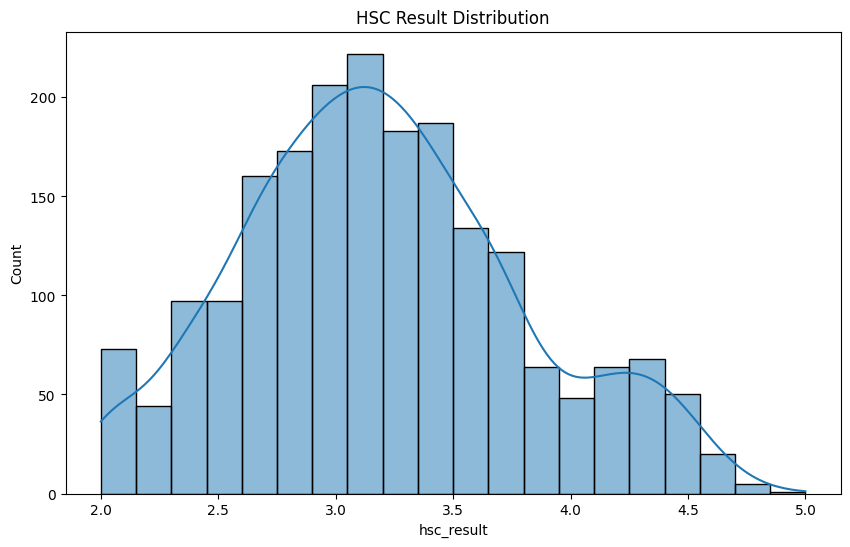

In [9]:
plt.figure(figsize=(10, 6))
sns.histplot(df["hsc_result"], bins=20, kde=True)
plt.title("HSC Result Distribution")
plt.show() 

Gender Distribution:
gender
M    1102
F     916
Name: count, dtype: int64


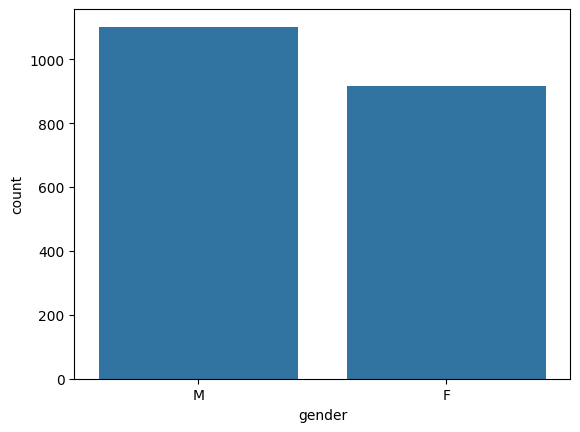

In [10]:
# Count of M and F

print("Gender Distribution:")
print(df["gender"].value_counts())

sns.countplot(
    x = "gender",
    data = df
)

plt.show()

Smoker Distribution:
smoker
No     1861
Yes     157
Name: count, dtype: int64


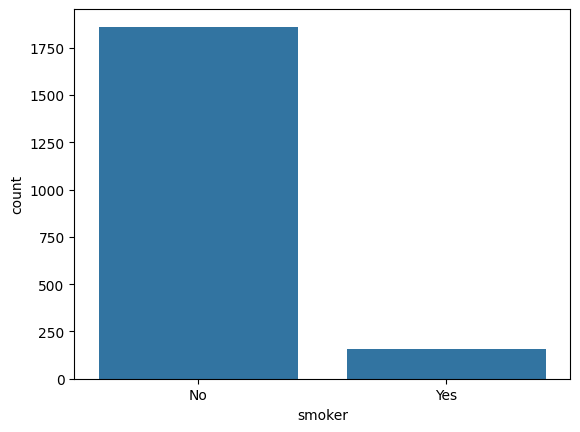

In [11]:
# Smoker Distribution
print("Smoker Distribution:")
print(df["smoker"].value_counts())

sns.countplot(
    x = "smoker",
    data = df
)   

plt.show()

In [12]:
# show all index
print(df.columns)

Index(['gender', 'age', 'address', 'famsize', 'pstatus', 'm_edu', 'f_edu',
       'm_job', 'f_job', 'relationship', 'smoker', 'tuition_fee',
       'time_friends', 'ssc_result', 'hsc_result'],
      dtype='object')


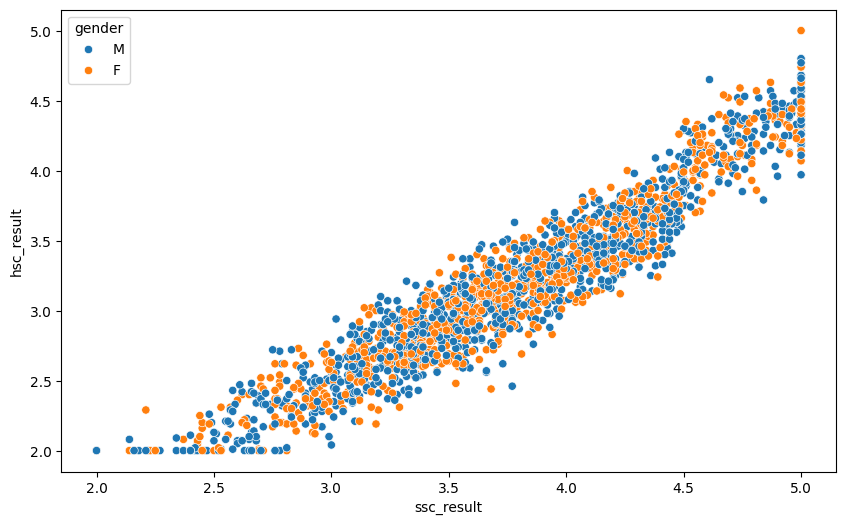

In [13]:
plt.figure(figsize=(10, 6))

# change hue to check the relationships
hue = "gender"  # You can change this to

sns.scatterplot(
    x = "ssc_result",
    y = "hsc_result",
    data = df,
    hue = hue
)   

plt.show()

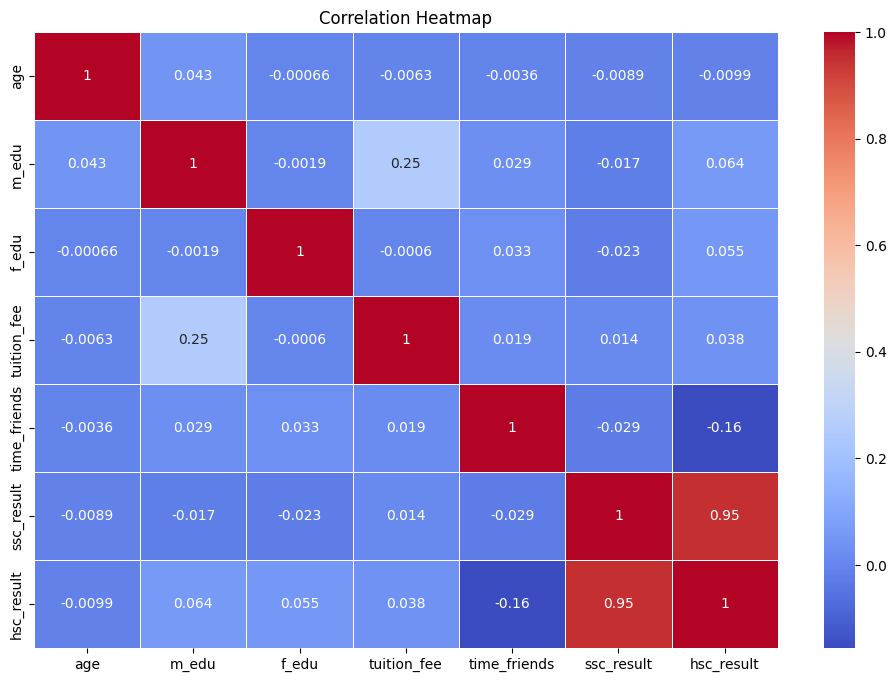

In [14]:
# Correlation Heatmap

numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(12, 8))

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [15]:
# Splitting the data 
X = df.drop("hsc_result", axis=1)
y = df["hsc_result"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [16]:
# Columns 
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(include=np.number).columns

# PipeLine

In [17]:
num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])


preprocessor = ColumnTransformer(transformers=[
    ("num", num_transformer, numerical_cols),
    ("cat", cat_transformer, categorical_cols)
]) 


# Base_learners 

base_learners = [
    ("lr", LinearRegression()),
    ("rf", RandomForestRegressor(n_estimators=100, random_state=42)),
    ("gb", GradientBoostingRegressor(n_estimators=100, random_state=42)),
]

meta_learner = Ridge()

voting_regressor = VotingRegressor(estimators=base_learners)
stacking_regressor = StackingRegressor(
    estimators=base_learners,
    final_estimator=meta_learner
)   

In [18]:
models = {
    "Voting Regressor": voting_regressor,
    "Stacking Regressor": stacking_regressor,
    "LinearRegression": 
        LinearRegression(),
    "Random Forest": 
        RandomForestRegressor(
            n_estimators=100,
            random_state=42
        ),
    "Gradient Boosting": 
        GradientBoostingRegressor(
            n_estimators=100,
            random_state=42
        ),
    "XGBoost": 
        XGBRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=5,
            random_state=42
    )
}       

In [19]:
results = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
    
    pred = pipe.predict(X_test)
    
    r2 = r2_score(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    
    results.append({
        "Model": name,
        "R2 Score": r2,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse
    })

In [20]:
results_df = pd.DataFrame(results)
results_df.sort_values(by="R2 Score", ascending=False, inplace=True)
results_df.reset_index(drop=True, inplace=True)
print(results_df)

                Model  R2 Score       MAE       MSE      RMSE
0  Stacking Regressor  0.960148  0.097254  0.014941  0.122231
1   Gradient Boosting  0.959840  0.097982  0.015056  0.122703
2    Voting Regressor  0.958989  0.098811  0.015375  0.123997
3             XGBoost  0.954485  0.104237  0.017064  0.130629
4       Random Forest  0.953531  0.105572  0.017421  0.131990
5    LinearRegression  0.946636  0.110812  0.020006  0.141443


In [21]:
best_model_name = results_df.loc[0, "Model"]
best_model = models[best_model_name]    
print(f"Best Model: {best_model_name}") 

Best Model: Stacking Regressor


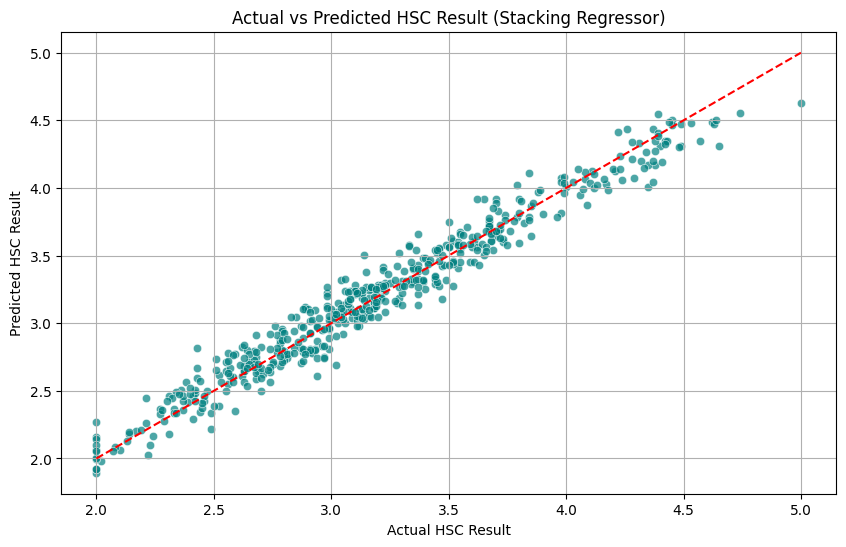

In [22]:
final_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", best_model)
])

final_model.fit(X_train, y_train)

y_final_pred = final_model.predict(X_test)

# plot 
plt.figure(figsize=(10, 6)) 
sns.scatterplot(
    x = y_test, y = y_final_pred,
    alpha = 0.7, color = "teal"
)

plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    color = "red", linestyle = "--"
)

plt.xlabel("Actual HSC Result")
plt.ylabel("Predicted HSC Result")
plt.title(f"Actual vs Predicted HSC Result ({best_model_name})")

plt.grid(True)
plt.show()

# Cross Validation 

In [23]:
rf_pipe = Pipeline(
    steps=
    [
        ("preprocessor", preprocessor),
        (
            "model", 
            RandomForestRegressor(
                n_estimators=100,
                random_state=42
            )
        )
    ]
)

In [24]:
cv_scores = cross_val_score(rf_pipe, X_train, y_train, cv=5, scoring="neg_mean_squared_error") 
cv_rmse_scores = np.sqrt(-cv_scores) 

print("Cross-Validation RMSE Scores:", cv_rmse_scores)
print("Mean CV RMSE:", cv_rmse_scores.mean())
print("Standard Deviation of CV RMSE:", cv_rmse_scores.std())

Cross-Validation RMSE Scores: [0.1367073  0.14959885 0.14946362 0.14044709 0.13028209]
Mean CV RMSE: 0.1412997890715635
Standard Deviation of CV RMSE: 0.007466329367540347


In [25]:
stacking_pipe = Pipeline(
    steps=
    [
        ("preprocessor", preprocessor),
        (
            "model", 
            StackingRegressor(
                estimators=base_learners,
                final_estimator=meta_learner
            )
        )
    ]
)

In [26]:
stack_cv_scores = cross_val_score(
    stacking_pipe,
    X_train, y_train, 
    cv = 5,
    scoring = "neg_mean_squared_error",
    n_jobs = -1    
)

cv_rmse_scores = np.sqrt(-stack_cv_scores)
print("Cross-Validation RMSE Scores:", cv_rmse_scores)

Cross-Validation RMSE Scores: [0.12870711 0.13341995 0.13054556 0.12894797 0.11518303]


# GridSearchCV

In [27]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model", 
            RandomForestRegressor(
                n_estimators=100,
                random_state=42
            )
        )
    ]
) 


In [28]:
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
}

In [29]:
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose = 2
)

In [30]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=200; total time=   1.7s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=200; total time=   1.8s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=200; total time=   1.8s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=100; total time=   0.8s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=300; total time=   2.5s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=300; total time=   2.6s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=100; total time=   0.8s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=100; total time=   0.9s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=100; total time=   0.9s
[CV

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 10, ...], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fol

In [31]:
print("Best Score (Negative RMSE):", grid_search.best_score_)
print("Best Parameters:", grid_search.best_params_)

Best Score (Negative RMSE): -0.14002046114821867
Best Parameters: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 300}


# RadomizedSearchCV

In [32]:
from scipy.stats import randint

In [33]:
param_dist = {
    "model__n_estimators": randint(100, 500),
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": randint(1, 10),
}

random_search = RandomizedSearchCV(
    estimator = rf_pipeline,
    param_distributions = param_dist,
    n_iter = 50,
    cv = 5, 
    scoring = "neg_root_mean_squared_error",
    n_jobs = -1,
    random_state = 42,
    verbose = 2
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END model__max_depth=None, model__min_samples_split=7, model__n_estimators=221; total time=   1.2s
[CV] END model__max_depth=None, model__min_samples_split=7, model__n_estimators=221; total time=   1.5s
[CV] END model__max_depth=20, model__min_samples_split=8, model__n_estimators=288; total time=   1.6s
[CV] END model__max_depth=20, model__min_samples_split=8, model__n_estimators=288; total time=   1.7s
[CV] END model__max_depth=20, model__min_samples_split=8, model__n_estimators=288; total time=   1.7s[CV] END model__max_depth=20, model__min_samples_split=8, model__n_estimators=288; total time=   1.7s

[CV] END model__max_depth=20, model__min_samples_split=8, model__n_estimators=288; total time=   1.8s
[CV] END model__max_depth=None, model__min_samples_split=7, model__n_estimators=221; total time=   1.4s
[CV] END model__max_depth=20, model__min_samples_split=4, model__n_estimators=448; total time=   2.9s
[CV] END model

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [None, 10, ...], 'model__min_samples_split': <scipy.stats....x7c91e02e5700>, 'model__n_estimators': <scipy.stats....x7c91e0357fe0>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-val

In [34]:
print("Best Score (Negative RMSE):", random_search.best_score_)
print("Best Parameters:", random_search.best_params_)

Best Score (Negative RMSE): -0.13989915312685103
Best Parameters: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 364}


In [35]:
import pickle 

filename = "best_rf_model.pkl"
with open(filename, "wb") as file: 
    pickle.dump(random_search.best_estimator_, file)

In [36]:
# using the saved model for prediction
with open(filename, "rb") as file:
    loaded_model = pickle.load(file)
    

y_loaded_pred = loaded_model.predict(X_test)

print("R2 Score of Loaded Model:", r2_score(y_test, y_loaded_pred))

R2 Score of Loaded Model: 0.953044708700144
